In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Base data folder
WORK = Path(os.environ.get("WORK", Path.cwd()))
DATA = WORK / "color-concept-entanglement" / "data"

In [2]:
gpt_df = pd.read_csv(DATA / "GPT_results/evaluation_gpt-4o_combined.csv")
llava_df = pd.read_csv(DATA / "LLaVA-NeXT_results/evaluation_llava-v1.6-mistral-7b-hf_combined.csv")
qwen_df = pd.read_csv(DATA / "Qwen3_results/evaluation_Qwen3-VL-8B-Instruct_combined.csv")

display(gpt_df.head())
print(gpt_df.shape)
display(llava_df.head())
print(llava_df.shape)
display(qwen_df.head())
print(qwen_df.shape)

,image_path,object,correct_answer,predicted_color,logprob_pred_token,logprob_correct_token,correct_in_top_k,calibration,response_label,intro_position,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,variant_label,mode
0,/mnt/lustre/work/eickhoff/esx061/color-concept...,cheese,white,black,-0.893953,-1.393953,True,NaN,black,last,correct_prior,yellow,white,BG,80,BG 80% (seq),seq
1,/mnt/lustre/work/eickhoff/esx061/color-concept...,espresso maker,red,black,-0.318641,NaN,False,NaN,black,last,correct_prior,red,red,FG,5,FG 5% (seq),seq
2,/mnt/lustre/work/eickhoff/esx061/color-concept...,tile roof,red,red,-0.000585,-0.000585,True,NaN,red,last,correct_prior,red,red,FG,100,FG 100% (seq),seq
3,/mnt/lustre/work/eickhoff/esx061/color-concept...,cloud,grey,grey,-0.004357,-0.004357,True,NaN,grey,last,correct_prior,grey,grey,FG,55,FG 55% (seq),seq
4,/mnt/lustre/work/eickhoff/esx061/color-concept...,frilled lizard,brown,brown,-0.000067,-0.000067,True,NaN,brown,last,correct_prior,brown,brown,FG,100,FG 100% (seq),seq


(9009, 17)


,image_path,object,correct_answer,predicted_color,logprob_pred_token,logprob_correct_token,correct_in_top_k,calibration,response_label,intro_position,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,variant_label,mode
0,/mnt/lustre/work/eickhoff/esx061/color-concept...,cheese,white,white,-0.256501,-10.654939,False,NaN,white,last,correct_prior,yellow,white,BG,80,BG 80% (seq),seq
1,/mnt/lustre/work/eickhoff/esx061/color-concept...,espresso maker,red,black,-1.101001,-12.749438,False,NaN,black,last,correct_prior,red,red,FG,5,FG 5% (seq),seq
2,/mnt/lustre/work/eickhoff/esx061/color-concept...,tile roof,red,red,-0.028346,-11.536159,False,NaN,red,last,correct_prior,red,red,FG,100,FG 100% (seq),seq
3,/mnt/lustre/work/eickhoff/esx061/color-concept...,cloud,grey,grey,-0.142373,-14.216591,False,NaN,grey,last,correct_prior,grey,grey,FG,55,FG 55% (seq),seq
4,/mnt/lustre/work/eickhoff/esx061/color-concept...,frilled lizard,brown,brown,-0.161806,-10.232119,False,NaN,brown,last,correct_prior,brown,brown,FG,100,FG 100% (seq),seq


(6006, 17)


,image_path,object,correct_answer,predicted_color,logprob_pred_token,logprob_correct_token,correct_in_top_k,calibration,response_label,intro_position,stimulus_type,manipulation_color,target_color,variant_region,percent_colored,variant_label,mode
0,/mnt/lustre/work/eickhoff/esx061/color-concept...,cheese,white,white,-0.111229,-0.111229,True,NaN,white,last,correct_prior,yellow,white,BG,80,BG 80% (seq),seq
1,/mnt/lustre/work/eickhoff/esx061/color-concept...,espresso maker,red,red,-0.680644,-0.711894,True,NaN,red,last,correct_prior,red,red,FG,5,FG 5% (seq),seq
2,/mnt/lustre/work/eickhoff/esx061/color-concept...,tile roof,red,red,-0.020549,-0.020549,True,NaN,red,last,correct_prior,red,red,FG,100,FG 100% (seq),seq
3,/mnt/lustre/work/eickhoff/esx061/color-concept...,cloud,grey,grey,-0.045944,-6.764694,True,NaN,grey,last,correct_prior,grey,grey,FG,55,FG 55% (seq),seq
4,/mnt/lustre/work/eickhoff/esx061/color-concept...,frilled lizard,brown,brown,-0.040452,-0.040452,True,NaN,brown,last,correct_prior,brown,brown,FG,100,FG 100% (seq),seq


(6006, 17)


In [3]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

colors = {

    # Main response colors
    "white": "#9E9E9E",        # medium grey
    "color": "#2C6DB2",        # academic blue

    # Experimental conditions
    "first": "#4C9F70",        # teal / green
    "last": "#2C3E50",         # dark blue

    # Additional useful accents
    "light_blue": "#6BAED6",   # lighter blue (confidence bands etc.)
    "dark_blue": "#1B3A6F",    # stronger blue
    "light_grey": "#D3D3D3",   # background or baseline
    "dark_grey": "#5A5A5A",    # outlines or secondary curves

    # Threshold / reference lines
    "threshold": "#444444",
    "highlight": "#7B3294",     # occasional highlight (purple)

    # Condition-specific colors
    'all': '#2E86AB',           # blue
    'correct_prior': '#6A994E', # Green
    'shape': '#F18F01',           # Orange
    'counterfact': '#A23B72',     # Professional magenta
}

plt.rcParams.update({
    # font
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    # sizes
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11, #10
    "figure.titlesize": 18, #14

    # cleaner academic look
    "axes.spines.top": False,
    "axes.spines.right": False
})

In [4]:
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D

# Custom legend handler for multi-colored line segments
class MultiColorLineHandler(HandlerBase):
    def __init__(self, colors, lw=3, linestyle='-', marker=None, **kwargs):
        self.colors = colors
        self.lw = lw
        self.linestyle = linestyle
        self.marker = marker
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):

        n = len(self.colors)
        segment_width = width / n
        artists = []

        # Continuous segments (no visual gaps)
        for i, color in enumerate(self.colors):
            line = Line2D(
                [x0 + i * segment_width, x0 + (i + 1) * segment_width],
                [y0 + height / 2, y0 + height / 2],
                lw=self.lw,
                color=color,
                linestyle=self.linestyle,
                solid_capstyle='butt',  # removes segment rounding gaps
                transform=trans
            )
            artists.append(line)

        # Optional centered marker
        if self.marker is not None:
            marker = Line2D(
                [x0 + width / 2],
                [y0 + height / 2],
                marker=self.marker,
                color='black',
                markerfacecolor='black',
                markersize=fontsize * 0.6,
                lw=0,
                transform=trans
            )
            artists.append(marker)

        return artists

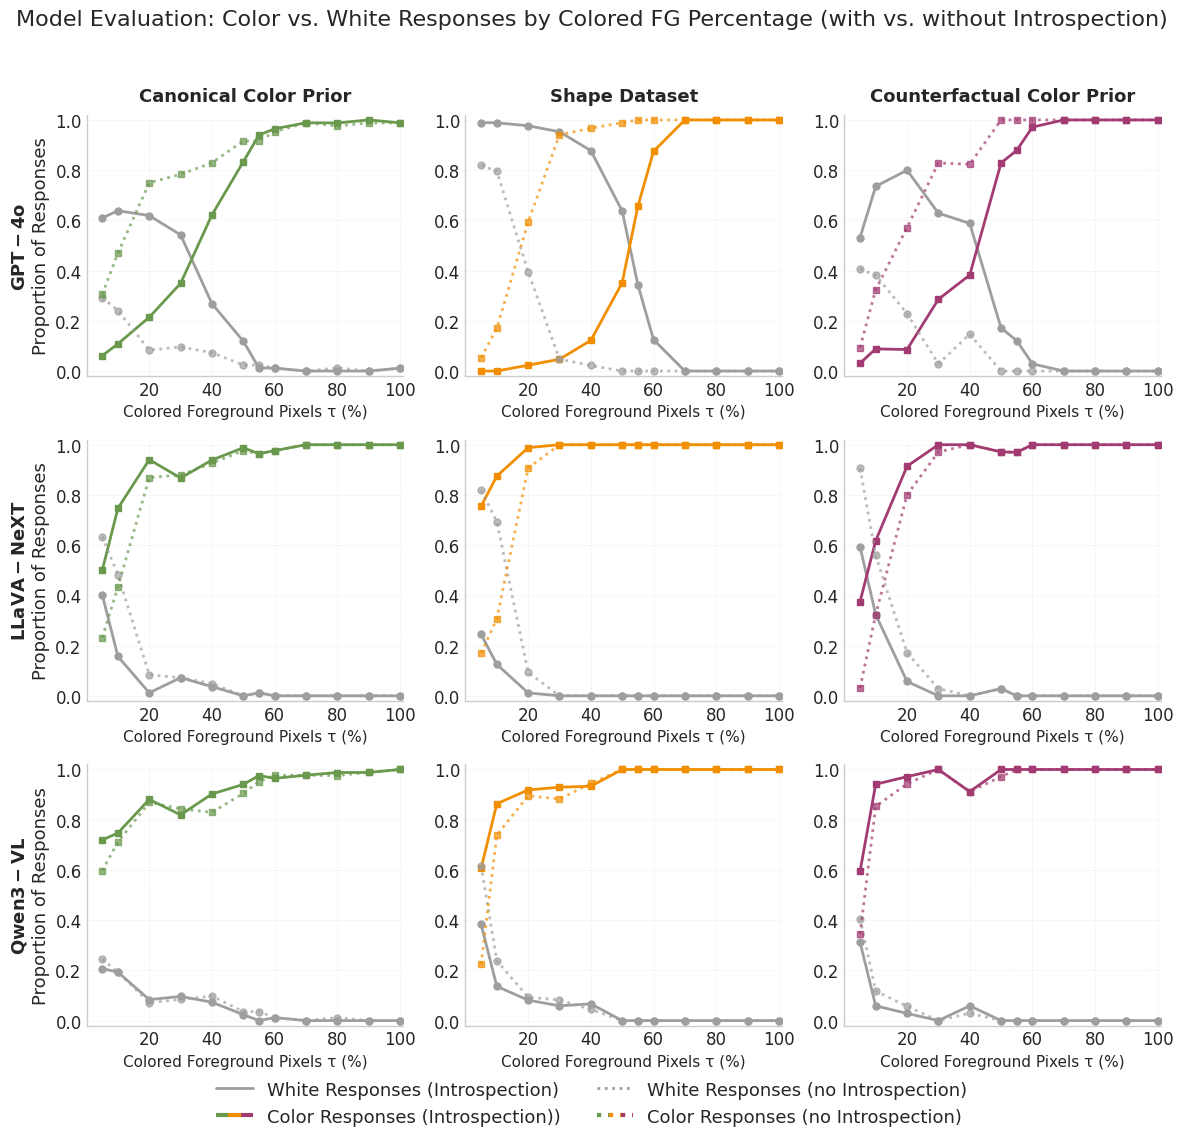

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

models = {
    "GPT-4o": gpt_df,
    "LLaVA-NeXT": llava_df,
    "Qwen3-VL": qwen_df
}

stimulus_types = ['correct_prior', 'shape', 'counterfact']

stimulus_labels = {
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

fig, axes = plt.subplots(3,3, figsize=(12,11))

# =========================
# MODEL LOOP
# =========================

for row,(model_name, df_model) in enumerate(models.items()):

    df_model = df_model.copy()
    df_model = df_model[df_model['variant_region']=='FG']
    df_model = df_model[df_model["percent_colored"] > 0]

    df_model['white_count'] = (df_model['response_label']=='white').astype(int)
    df_model['color_count'] = (df_model['response_label']==df_model['manipulation_color']).astype(int)

    """print(f"{model_name}\n") 
    
    wrong_color = (
    (df_model['response_label']!='white') &
    (df_model['response_label']!=df_model['target_color'])
    )
    print(df_model[wrong_color]["percent_colored"].value_counts())
    display(df_model[wrong_color])
    """
    for col,stim_type in enumerate(stimulus_types):

        ax = axes[row,col]

        for position in ['first','last']:

            df_subset = df_model[
                (df_model['stimulus_type']==stim_type) &
                (df_model['intro_position']==position)
            ]

            grouped = (
                df_subset
                .groupby('percent_colored')[['white_count','color_count']]
                .mean()
                .reset_index()
                .sort_values('percent_colored')
            )

            linestyle = '-' if position=='first' else ':'
            alpha = 1.0 if position=='first' else 0.7

            ax.plot(
                grouped['percent_colored'],
                grouped['white_count'],
                color=colors['white'],
                marker='o',
                markersize=5,
                linewidth=2,
                linestyle=linestyle,
                alpha=alpha
            )

            ax.plot(
                grouped['percent_colored'],
                grouped['color_count'],
                color=colors[stim_type],
                marker='s',
                markersize=5,
                linewidth=2,
                linestyle=linestyle,
                alpha=alpha
            )

        # titles
        if row == 0:
            ax.set_title(
                stimulus_labels[stim_type],
                fontsize=13,
                fontweight='bold',
                pad=10
            )

        # model labels on left
        if col == 0:
            
            ax.set_ylabel(
                rf"$\bf{{ {model_name} }}$" 
                "\nProportion of Responses",
                fontsize=13
            )

        ax.set_xlabel('Colored Foreground Pixels τ (%)', fontsize=11)

        ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

        ax.set_xlim(0,101)
        ax.set_ylim(-0.02,1.02)

        # explicit x ticks
        ax.set_xticks(np.arange(20,101,20))

# =========================
# MATCH Y LIMITS
# =========================

y_min = min(ax.get_ylim()[0] for ax in axes.flatten())
y_max = max(ax.get_ylim()[1] for ax in axes.flatten())

for ax in axes.flatten():
    ax.set_ylim([y_min,y_max])

# =========================
# LEGEND (same style as human plot)
# =========================

multi_color_solid = object()
multi_color_dotted = object()

legend_elements = [
    Line2D([0],[0],
           color=colors['white'],
           lw=2,
           linestyle='-',
           label='White Responses (First)'),

    multi_color_solid,

    Line2D([0],[0],
           color=colors['white'],
           lw=2,
           linestyle=':',
           label='White Responses (Last)'),

    multi_color_dotted
]

legend_labels = [
    'White Responses (Introspection)',
    'Color Responses (Introspection))',
    'White Responses (no Introspection)',
    'Color Responses (no Introspection)'
]

fig.legend(
    legend_elements,
    legend_labels,
    handler_map={
        multi_color_solid: MultiColorLineHandler(
            colors=[
                colors['correct_prior'],
                colors['shape'],
                colors['counterfact']
            ],
            lw=3,
            linestyle='-'
        ),
        multi_color_dotted: MultiColorLineHandler(
            colors=[
                colors['correct_prior'],
                colors['shape'],
                colors['counterfact']
            ],
            lw=3,
            linestyle=':'
        )
    },
    loc='lower center',
    bbox_to_anchor=(0.5,-0.05),
    ncol=2,
    frameon=False,
    fontsize=13
)

# =========================
# TITLE
# =========================

plt.suptitle(
    "Model Evaluation: Color vs. White Responses by Colored FG Percentage (with vs. without Introspection)",
    fontsize=16
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()


GPT-4o
    percent_colored       sum
0                 0  0.998095
1                 5  0.969551
2                10  0.990244
3                20  0.988618
4                30  0.988506
5                40  0.998382
6                50  0.990476
7                55  1.000000
8                60  0.998397
9                70  0.995349
10               80  1.000000
11               90  1.000000
12              100  1.000000

LLaVA-NeXT
    percent_colored       sum
0                 0  0.997143
1                 5  0.995192
2                10  1.000000
3                20  1.000000
4                30  1.000000
5                40  1.000000
6                50  1.000000
7                55  1.000000
8                60  1.000000
9                70  1.000000
10               80  1.000000
11               90  1.000000
12              100  1.000000

Qwen3-VL
    percent_colored       sum
0                 0  0.994286
1                 5  0.985577
2                10  0.992683
3         

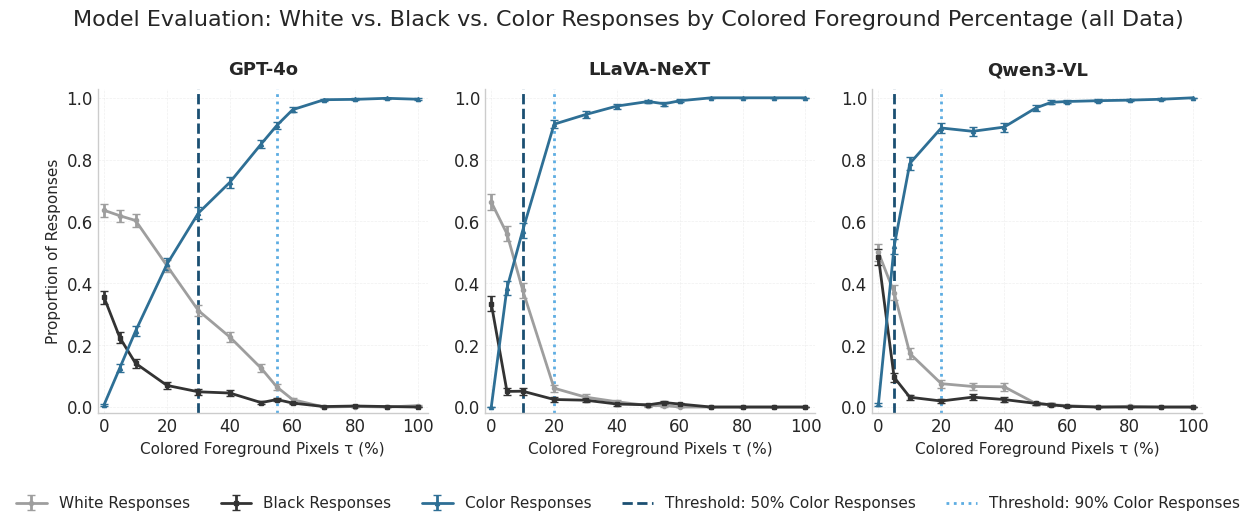

In [28]:
import matplotlib.pyplot as plt
import numpy as np

models = {
    "GPT-4o": gpt_df,
    "LLaVA-NeXT": llava_df,
    "Qwen3-VL": qwen_df
}

fig, axes = plt.subplots(1, 3, figsize=(12,5))


def find_threshold(df, col, thresh):
    above = df[df[col] > thresh]
    if len(above) > 0:
        return above["percent_colored"].iloc[0]
    return None


for ax, (model_name, df_model) in zip(axes, models.items()):

    df_model = df_model.copy()
    df_model = df_model[df_model["variant_region"] == "FG"]

    # indicators
    df_model["white"] = (df_model["response_label"] == "white").astype(int)
    df_model["black"] = (df_model["response_label"] == "black").astype(int)
    df_model["color"] = (df_model["response_label"] == df_model["manipulation_color"]).astype(int)

    grouped = (
        df_model
        .groupby("percent_colored")
        .agg(
            white_mean=("white","mean"),
            white_sem=("white","sem"),
            black_mean=("black","mean"),
            black_sem=("black","sem"),
            color_mean=("color","mean"),
            color_sem=("color","sem")
        )
        .reset_index()
        .sort_values("percent_colored")
    )

    grouped["sum"] = grouped["white_mean"] + grouped["black_mean"] + grouped["color_mean"]

    print("\n", "="*60)
    print(model_name)
    print(grouped[["percent_colored","sum"]])

    # thresholds
    crossover_50 = find_threshold(grouped, "color_mean", 0.5)
    threshold_90 = find_threshold(grouped, "color_mean", 0.9)

    # white
    ax.errorbar(
        grouped["percent_colored"],
        grouped["white_mean"],
        yerr=grouped["white_sem"],
        color="#9E9E9E",
        marker="o",
        markersize=3,
        linewidth=2,
        capsize=3,
        label="White Responses",
        zorder=3
    )

    # black
    ax.errorbar(
        grouped["percent_colored"],
        grouped["black_mean"],
        yerr=grouped["black_sem"],
        color="#333333",
        marker="s",
        markersize=3,
        linewidth=2,
        capsize=3,
        label="Black Responses",
        zorder=3
    )

    # color
    ax.errorbar(
        grouped["percent_colored"],
        grouped["color_mean"],
        yerr=grouped["color_sem"],
        color="#2E6F95",
        marker="^",
        markersize=3,
        linewidth=2,
        capsize=3,
        label="Color Responses",
        zorder=3
    )

    # threshold lines
    if crossover_50 is not None:
        ax.axvline(
            crossover_50,
            color="#1B4F72",
            linestyle="--",
            linewidth=2,
            label="Threshold: 50% Color Responses"
        )

    if threshold_90 is not None:
        ax.axvline(
            threshold_90,
            color="#5DADE2",
            linestyle=":",
            linewidth=2,
            label="Threshold: 90% Color Responses"
        )

    ax.set_title(model_name, fontsize=13, fontweight="bold", pad=10)

    ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)

    ax.set_xlim(-2,103)
    ax.set_ylim(-0.02,1.03)

    ax.set_xticks(np.arange(0,101,20))
    ax.set_yticks(np.linspace(0,1,6))

    ax.set_xlabel("Colored Foreground Pixels τ (%)", fontsize=11)


axes[0].set_ylabel("Proportion of Responses", fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()

desired_order = [
    "White Responses",
    "Black Responses",
    "Color Responses",
    "Threshold: 50% Color Responses",
    "Threshold: 90% Color Responses"
]

order = [labels.index(label) for label in desired_order]

handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5,-0.05),
    ncol=5,
    frameon=False,
    fontsize=11
)

plt.suptitle(
    "Model Evaluation: White vs. Black vs. Color Responses by Colored Foreground Percentage (all Data)",
    fontsize=16
)

plt.tight_layout(rect=[0,0.05,1,0.99])

plt.show()

In [29]:
def find_empirical_threshold(df):
    
    grouped = (
        df.groupby("percent_colored")["color_response"]
        .mean()
        .reset_index()
        .sort_values("percent_colored")
    )

    above = grouped[grouped["color_response"] > 0.5]

    if len(above) > 0:
        return above["percent_colored"].iloc[0]

    return np.nan


records = []

for model_name, df_model in models.items():

    df_model = df_model.copy()
    df_model = df_model[df_model["variant_region"] == "FG"]

    df_model["color_response"] = (
        df_model["response_label"] == df_model["manipulation_color"]
    ).astype(int)

    for stim in stimulus_types:

        df_stim = df_model[df_model["stimulus_type"] == stim]

        # stated threshold
        stated = (
            df_stim["calibration"]
            .dropna()
            .astype(float)
            .mean()
        )

        # introspection condition
        df_intro = df_stim[df_stim["intro_position"] == "first"]
        emp_intro = find_empirical_threshold(df_intro)

        # no introspection
        df_no = df_stim[df_stim["intro_position"] == "last"]
        emp_no = find_empirical_threshold(df_no)

        records.append({
            "model": model_name,
            "stimulus": stim,
            "stated": stated,
            "empirical_intro": emp_intro,
            "empirical_no_intro": emp_no
        })

calib_df = pd.DataFrame(records)

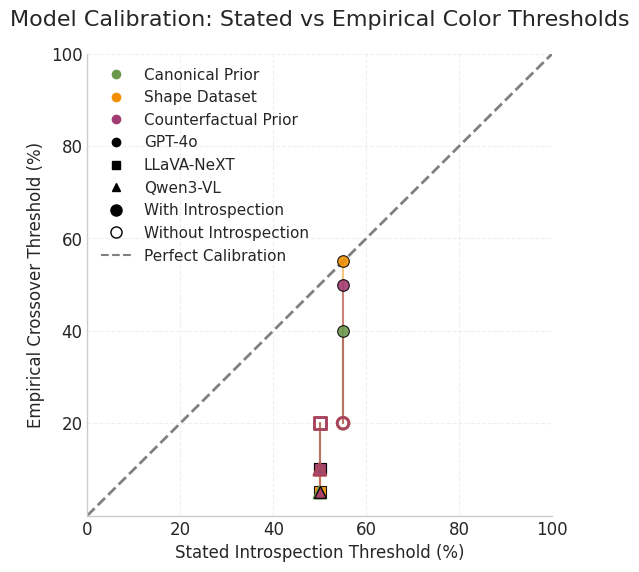

In [38]:
calib_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(6,6))

model_markers = {
    "GPT-4o": "o",
    "LLaVA-NeXT": "s",
    "Qwen3-VL": "^"
}

# deterministic offsets to avoid overlap
model_offsets = {
    "GPT-4o": 0, #-1.2,
    "LLaVA-NeXT": 0,
    "Qwen3-VL": 0, #1.2
}

# diagonal reference
ax.plot([0,100], [0,100],
        linestyle="--",
        color="gray",
        linewidth=2)

for _, row in calib_df.iterrows():

    marker = model_markers[row["model"]]
    color = colors[row["stimulus"]]

    # apply offset
    x = row["stated"] + model_offsets[row["model"]]

    # connect intro vs no-intro with thin line
    ax.plot(
        [row["stated"], row["stated"]],
        [row["empirical_no_intro"], row["empirical_intro"]],
        color=color,
        linewidth=1.5,
        alpha=0.5,
        zorder=2
    )

    # with introspection
    ax.scatter(
        x,
        row["empirical_intro"],
        marker=marker,
        s=70,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        zorder=3
    )

    # without introspection
    ax.scatter(
        x,
        row["empirical_no_intro"],
        marker=marker,
        s=70,
        facecolors="none",
        edgecolor=color,
        linewidth=2,
        alpha=0.9,
        zorder=3
    )

ax.set_xlabel("Stated Introspection Threshold (%)")
ax.set_ylabel("Empirical Crossover Threshold (%)")

ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.set_yticks(np.arange(20,101,20))

ax.grid(alpha=0.3, linestyle="--")

plt.title(
    "Model Calibration: Stated vs Empirical Color Thresholds",
    pad = 20,
    fontsize=16
)

from matplotlib.lines import Line2D

legend_elements = [

    # stimulus colors
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors['correct_prior'],
           markersize=8,
           label='Canonical Prior'),

    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors['shape'],
           markersize=8,
           label='Shape Dataset'),

    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=colors['counterfact'],
           markersize=8,
           label='Counterfactual Prior'),

    # models
    Line2D([0],[0], marker='o', color='black', linestyle='None', label='GPT-4o'),
    Line2D([0],[0], marker='s', color='black', linestyle='None', label='LLaVA-NeXT'),
    Line2D([0],[0], marker='^', color='black', linestyle='None', label='Qwen3-VL'),

    # introspection markers
    Line2D([0],[0], marker='o', color='black',
           markerfacecolor='black',
           markersize=8,
           linestyle='None',
           label='With Introspection'),

    Line2D([0],[0], marker='o', color='black',
           markerfacecolor='white',
           markersize=8,
           linestyle='None',
           label='Without Introspection'),

    # diagonal
    Line2D([0],[0],
           color='gray',
           linestyle='--',
           label='Perfect Calibration')
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=False
)

plt.show()

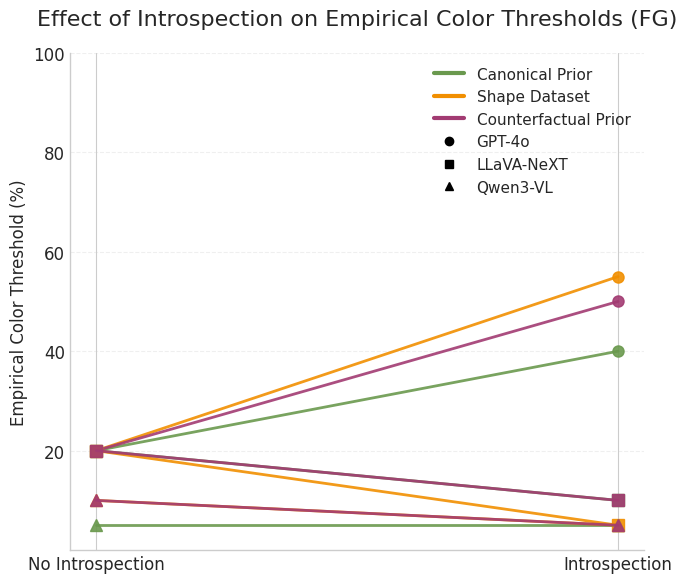

In [42]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7,6))

x_positions = [0,1]  # no introspection -> introspection

for _, row in calib_df.iterrows():

    y_vals = [
        row["empirical_no_intro"],
        row["empirical_intro"]
    ]

    ax.plot(
        x_positions,
        y_vals,
        color=colors[row["stimulus"]],
        marker=model_markers[row["model"]],
        markersize=8,
        linewidth=2,
        alpha=0.9
    )

# axes
ax.set_xticks(x_positions)
ax.set_xticklabels(["No Introspection","Introspection"])

ax.set_ylabel("Empirical Color Threshold (%)")
ax.set_ylim(0,100)
ax.set_yticks(np.arange(20,101,20))

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.title(
    "Effect of Introspection on Empirical Color Thresholds (FG)",
    fontsize=16,
    pad = 20
)

# legend
from matplotlib.lines import Line2D

legend_elements = [

    # datasets
    Line2D([0],[0], color=colors['correct_prior'], lw=3, label='Canonical Prior'),
    Line2D([0],[0], color=colors['shape'], lw=3, label='Shape Dataset'),
    Line2D([0],[0], color=colors['counterfact'], lw=3, label='Counterfactual Prior'),

    # models
    Line2D([0],[0], marker='o', color='black', linestyle='None', label='GPT-4o'),
    Line2D([0],[0], marker='s', color='black', linestyle='None', label='LLaVA-NeXT'),
    Line2D([0],[0], marker='^', color='black', linestyle='None', label='Qwen3-VL'),
]

ax.legend(handles=legend_elements, frameon=False)

plt.tight_layout()
plt.show()

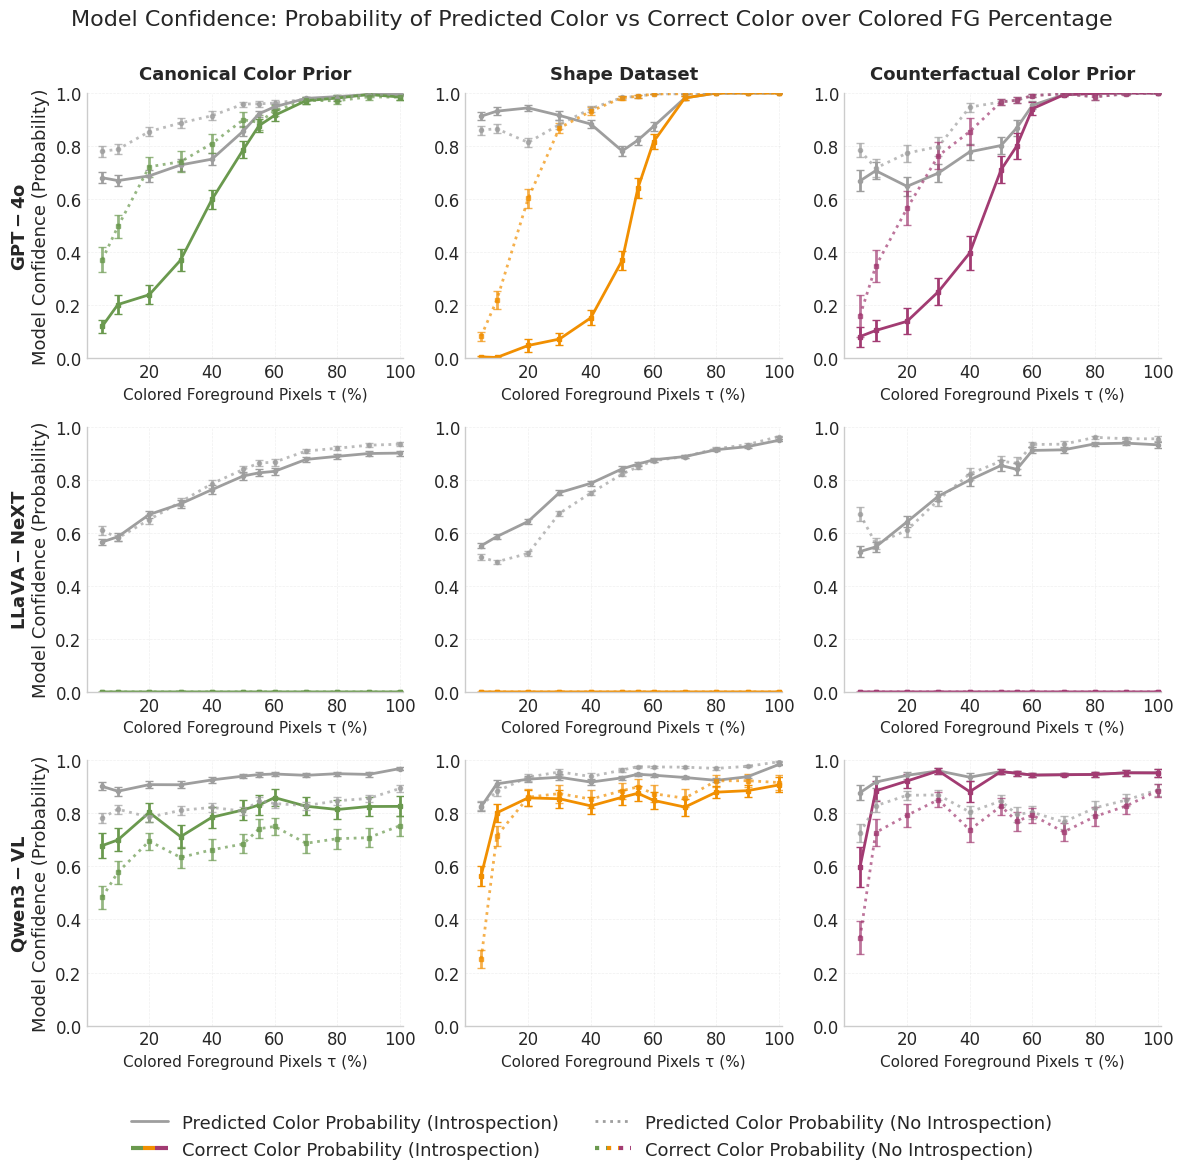

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =========================
# MODEL DATA
# =========================

models = {
    "GPT-4o": gpt_df,
    "LLaVA-NeXT": llava_df,
    "Qwen3-VL": qwen_df
}

stimulus_types = ['correct_prior', 'shape', 'counterfact']

stimulus_labels = {
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(3,3, figsize=(12,11))

# =========================
# MODEL LOOP
# =========================

for row,(model_name, df_model) in enumerate(models.items()):

    df_model = df_model.copy()
    df_model = df_model[df_model['variant_region'] == 'FG']
    df_model = df_model[df_model["percent_colored"] > 0]

    # convert logprobs → probabilities
    df_model["prob_correct"] = np.exp(df_model["logprob_correct_token"])
    df_model["prob_pred"] = np.exp(df_model["logprob_pred_token"])

    for col,stim_type in enumerate(stimulus_types):

        ax = axes[row,col]

        for position in ['first','last']:

            df_subset = df_model[
                (df_model['stimulus_type'] == stim_type) &
                (df_model['intro_position'] == position)
            ]

            grouped = (
                df_subset
                .groupby('percent_colored')
                .agg(
                    prob_pred_mean=('prob_pred','mean'),
                    prob_pred_sem=('prob_pred','sem'),
                    prob_correct_mean=('prob_correct','mean'),
                    prob_correct_sem=('prob_correct','sem')
                )
                .reset_index()
                .sort_values('percent_colored')
            )

            linestyle = '-' if position == 'first' else ':'
            alpha = 1.0 if position == 'first' else 0.7

            # predicted token confidence
            ax.errorbar(
                grouped['percent_colored'],
                grouped['prob_pred_mean'],
                yerr=grouped['prob_pred_sem'],
                color=colors['white'],
                marker='o',
                markersize=3,
                linewidth=2,
                capsize=3,
                linestyle=linestyle,
                alpha=alpha
            )

            # correct color confidence
            ax.errorbar(
                grouped['percent_colored'],
                grouped['prob_correct_mean'],
                yerr=grouped['prob_correct_sem'],
                color=colors[stim_type],
                marker='s',
                markersize=3,
                linewidth=2,
                capsize=3,
                linestyle=linestyle,
                alpha=alpha
            )

        # titles
        if row == 0:
            ax.set_title(
                stimulus_labels[stim_type],
                fontsize=13,
                fontweight='bold',
                pad=10
            )

        # model labels
        if col == 0:
            ax.set_ylabel(
                rf"$\bf{{ {model_name} }}$" 
                "\nModel Confidence (Probability)",
                fontsize=13
            )
        
        ax.set_xlabel('Colored Foreground Pixels τ (%)', fontsize=11)

        ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

        ax.set_xlim(0,101)
        ax.set_ylim(0,1)

        ax.set_xticks(np.arange(20,101,20))
        ax.set_yticks(np.linspace(0,1,6))

# =========================
# MATCH Y LIMITS
# =========================

y_min = min(ax.get_ylim()[0] for ax in axes.flatten())
y_max = max(ax.get_ylim()[1] for ax in axes.flatten())

for ax in axes.flatten():
    ax.set_ylim([y_min,y_max])

# =========================
# LEGEND
# =========================

multi_color_solid = object()
multi_color_dotted = object()

legend_elements = [
    Line2D([0],[0],
           color=colors['white'],
           lw=2,
           linestyle='-',
           label='Predicted Token (Introspection)'),

    multi_color_solid,

    Line2D([0],[0],
           color=colors['white'],
           lw=2,
           linestyle=':',
           label='Predicted Token (No Introspection)'),

    multi_color_dotted
]

legend_labels = [
    'Predicted Color Probability (Introspection)',
    'Correct Color Probability (Introspection)',
    'Predicted Color Probability (No Introspection)',
    'Correct Color Probability (No Introspection)'
]

fig.legend(
    legend_elements,
    legend_labels,
    handler_map={
        multi_color_solid: MultiColorLineHandler(
            colors=[
                colors['correct_prior'],
                colors['shape'],
                colors['counterfact']
            ],
            lw=3,
            linestyle='-'
        ),
        multi_color_dotted: MultiColorLineHandler(
            colors=[
                colors['correct_prior'],
                colors['shape'],
                colors['counterfact']
            ],
            lw=3,
            linestyle=':'
        )
    },
    loc='lower center',
    bbox_to_anchor=(0.5,-0.08),
    ncol=2,
    frameon=False,
    fontsize=13
)

# =========================
# TITLE
# =========================

plt.suptitle(
    "Model Confidence: Probability of Predicted Color vs Correct Color over Colored FG Percentage",
    fontsize=16,
)

plt.tight_layout(rect=[0,0,1,0.98])

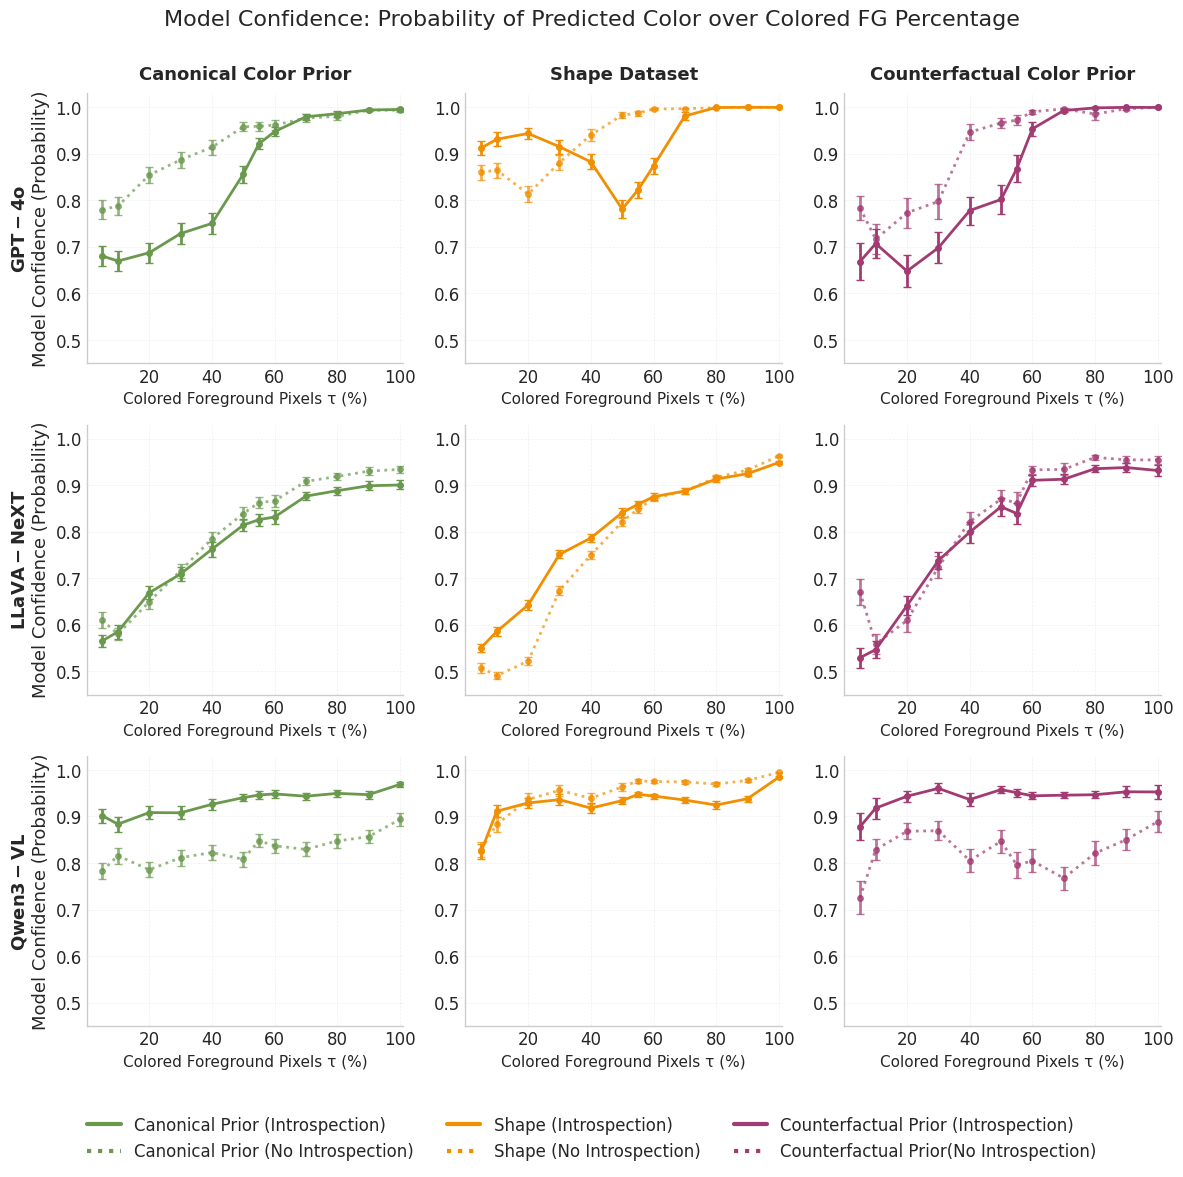

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =========================
# MODEL DATA
# =========================

models = {
    "GPT-4o": gpt_df,
    "LLaVA-NeXT": llava_df,
    "Qwen3-VL": qwen_df
}

stimulus_types = ['correct_prior', 'shape', 'counterfact']

stimulus_labels = {
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(3,3, figsize=(12,11))

# =========================
# MODEL LOOP
# =========================

for row,(model_name, df_model) in enumerate(models.items()):

    df_model = df_model.copy()
    df_model = df_model[df_model['variant_region'] == 'FG']
    df_model = df_model[df_model["percent_colored"] > 0]

    # convert logprob → probability
    df_model["prob_pred"] = np.exp(df_model["logprob_pred_token"])

    for col,stim_type in enumerate(stimulus_types):

        ax = axes[row,col]

        for position in ['first','last']:

            df_subset = df_model[
                (df_model['stimulus_type'] == stim_type) &
                (df_model['intro_position'] == position)
            ]

            grouped = (
                df_subset
                .groupby('percent_colored')
                .agg(
                    prob_mean=('prob_pred','mean'),
                    prob_sem=('prob_pred','sem')
                )
                .reset_index()
                .sort_values('percent_colored')
            )

            linestyle = '-' if position == 'first' else ':'
            alpha = 1.0 if position == 'first' else 0.7

            ax.errorbar(
                grouped['percent_colored'],
                grouped['prob_mean'],
                yerr=grouped['prob_sem'],
                color=colors[stim_type],
                marker='o',
                markersize=4,
                linewidth=2,
                capsize=3,
                linestyle=linestyle,
                alpha=alpha
            )

        # titles
        if row == 0:
            ax.set_title(
                stimulus_labels[stim_type],
                fontsize=13,
                fontweight='bold',
                pad=10
            )

        # model labels
        if col == 0:
            ax.set_ylabel(
                rf"$\bf{{ {model_name} }}$" 
                "\nModel Confidence (Predicted Token Probability)",
                fontsize=13
            )

        # model labels
        if col == 0:
            ax.set_ylabel(
                rf"$\bf{{ {model_name} }}$" 
                "\nModel Confidence (Probability)",
                fontsize=13
            )
        
        ax.set_xlabel('Colored Foreground Pixels τ (%)', fontsize=11)

        ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

        ax.set_xlim(0,101)
        ax.set_ylim(0.45,1.03)

        ax.set_xticks(np.arange(20,101,20))
        ax.set_yticks(np.arange(0.5,1.01,0.1))

# =========================
# LEGEND
# =========================

legend_elements = [

    # Canonical
    Line2D([0],[0],
           color=colors['correct_prior'],
           lw=3,
           linestyle='-',
           label='Canonical Prior (Introspection)'),

    Line2D([0],[0],
           color=colors['correct_prior'],
           lw=3,
           linestyle=':',
           label='Canonical Prior (No Introspection)'),


    # Shape
    Line2D([0],[0],
           color=colors['shape'],
           lw=3,
           linestyle='-',
           label='Shape (Introspection)'),

    Line2D([0],[0],
           color=colors['shape'],
           lw=3,
           linestyle=':',
           label='Shape (No Introspection)'),


    # Counterfactual
    Line2D([0],[0],
           color=colors['counterfact'],
           lw=3,
           linestyle='-',
           label='Counterfactual Prior (Introspection)'),

    Line2D([0],[0],
           color=colors['counterfact'],
           lw=3,
           linestyle=':',
           label='Counterfactual Prior(No Introspection)')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5,-0.08),
    ncol=3,   # one column per dataset
    frameon=False,
    fontsize=12
)

# =========================
# TITLE
# =========================

plt.suptitle(
    "Model Confidence: Probability of Predicted Color over Colored FG Percentage",
    fontsize=16,
)

plt.tight_layout(rect=[0,0,1,0.98])

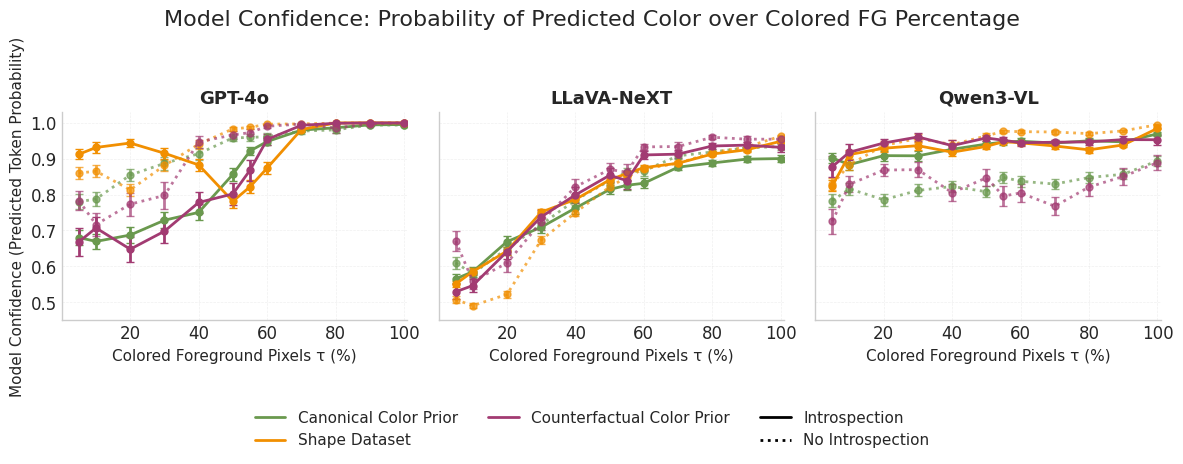

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =========================
# MODEL DATA
# =========================

models = {
    "GPT-4o": gpt_df,
    "LLaVA-NeXT": llava_df,
    "Qwen3-VL": qwen_df
}

stimulus_types = ['correct_prior', 'shape', 'counterfact']

stimulus_labels = {
    'correct_prior': 'Canonical Color Prior',
    'shape': 'Shape Dataset',
    'counterfact': 'Counterfactual Color Prior'
}

# =========================
# FIGURE
# =========================

fig, axes = plt.subplots(1,3, figsize=(12,4), sharey=True)

# =========================
# MODEL LOOP
# =========================

for ax,(model_name, df_model) in zip(axes, models.items()):

    df_model = df_model.copy()
    df_model = df_model[df_model['variant_region']=='FG']
    df_model = df_model[df_model["percent_colored"] > 0]

    # convert logprob → probability
    df_model["prob_pred"] = np.exp(df_model["logprob_pred_token"])

    for stim_type in stimulus_types:

        for position in ['first','last']:

            df_subset = df_model[
                (df_model['stimulus_type']==stim_type) &
                (df_model['intro_position']==position)
            ]

            grouped = (
                df_subset
                .groupby('percent_colored')
                .agg(
                    prob_mean=('prob_pred','mean'),
                    prob_sem=('prob_pred','sem')
                )
                .reset_index()
                .sort_values('percent_colored')
            )

            linestyle = '-' if position=='first' else ':'
            alpha = 1.0 if position=='first' else 0.7

            ax.errorbar(
                grouped['percent_colored'],
                grouped['prob_mean'],
                yerr=grouped['prob_sem'],
                color=colors[stim_type],
                marker='o',
                markersize=5,
                linewidth=2,
                capsize=3,
                linestyle=linestyle,
                alpha=alpha
            )

    ax.set_title(model_name, fontsize=13, fontweight='bold')

    ax.set_xlabel('Colored Foreground Pixels τ (%)', fontsize=11)

    ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

    ax.set_xlim(0,101)
    ax.set_ylim(0.45,1.03)

    ax.set_xticks(np.arange(20,101,20))
    ax.set_yticks(np.arange(0.5,1.01, 0.1))

axes[0].set_ylabel("Model Confidence (Predicted Token Probability)", fontsize=11)

# =========================
# LEGEND
# =========================

legend_elements = [

    Line2D([0],[0],
           color=colors['correct_prior'],
           lw=2,
           label='Canonical Color Prior'),

    Line2D([0],[0],
           color=colors['shape'],
           lw=2,
           label='Shape Dataset'),

    Line2D([0],[0],
           color=colors['counterfact'],
           lw=2,
           label='Counterfactual Color Prior'),

    Line2D([0],[0],
           color='white',
           lw=2,
           linestyle='-',
           label=''),

    Line2D([0],[0],
           color='black',
           lw=2,
           linestyle='-',
           label='Introspection'),

    Line2D([0],[0],
           color='black',
           lw=2,
           linestyle=':',
           label='No Introspection')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5,-0.15),
    ncol=3,
    frameon=False,
    fontsize=11
)

# =========================
# TITLE
# =========================

plt.suptitle(
    "Model Confidence: Probability of Predicted Color over Colored FG Percentage",
    fontsize=16
)

plt.tight_layout(rect=[0,0.05,1,0.92])

plt.show()

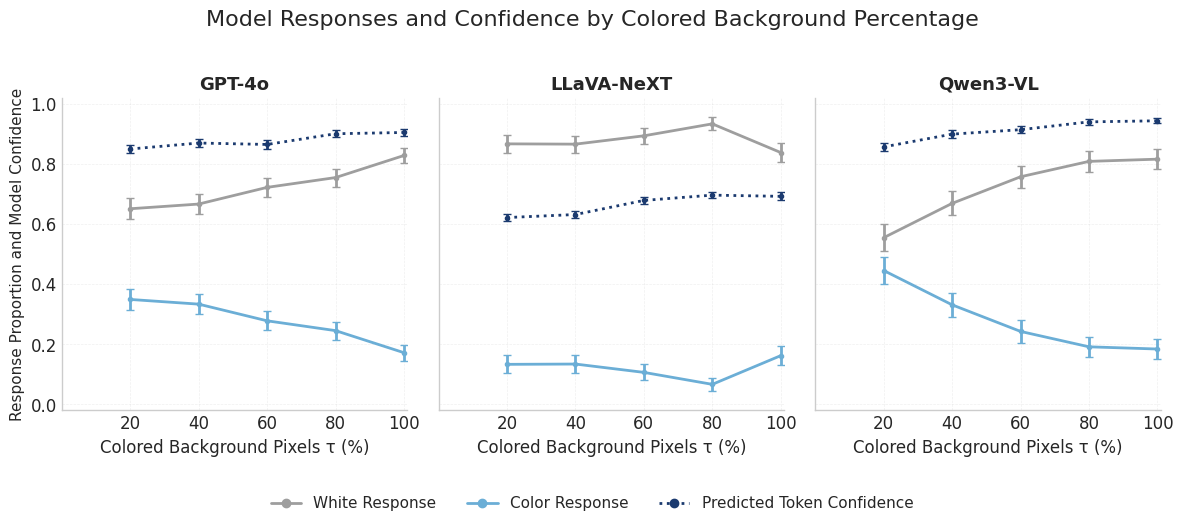

In [111]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =========================
# MODEL DATA
# =========================

models = {
    "GPT-4o": gpt_df,
    "LLaVA-NeXT": llava_df,
    "Qwen3-VL": qwen_df
}

fig, axes = plt.subplots(1,3, figsize=(12,5), sharey=True)

# =========================
# MODEL LOOP
# =========================

for ax,(model_name, df_model) in zip(axes, models.items()):

    df_model = df_model.copy()
    df_model = df_model[df_model["variant_region"] == "BG"]

    # response indicators
    df_model["white_count"] = (df_model["response_label"] == "white").astype(int)
    df_model["color_count"] = (df_model["response_label"] != "white").astype(int)

    # model confidence
    df_model["prob_pred"] = np.exp(df_model["logprob_pred_token"])

    grouped = (
        df_model
        .groupby("percent_colored")
        .agg(
            white_mean=("white_count","mean"),
            white_sem=("white_count","sem"),
            color_mean=("color_count","mean"),
            color_sem=("color_count","sem"),
            prob_mean=("prob_pred","mean"),
            prob_sem=("prob_pred","sem")
        )
        .reset_index()
        .sort_values("percent_colored")
    )

    # -------------------------
    # RESPONSE PROPORTIONS
    # -------------------------

    ax.errorbar(
        grouped["percent_colored"],
        grouped["white_mean"],
        yerr=grouped["white_sem"],
        color=colors["white"],
        marker="o",
        linewidth=2,
        markersize=3,
        capsize=3
    )

    ax.errorbar(
        grouped["percent_colored"],
        grouped["color_mean"],
        yerr=grouped["color_sem"],
        color=colors["light_blue"],
        marker="o",
        linewidth=2,
        markersize=3,
        capsize=3
    )

    # -------------------------
    # MODEL CONFIDENCE
    # -------------------------

    ax.errorbar(
        grouped["percent_colored"],
        grouped["prob_mean"],
        yerr=grouped["prob_sem"],
        color=colors["dark_blue"],
        linestyle=":",
        marker="o",
        linewidth=2,
        markersize=3,
        capsize=3
    )

    # -------------------------
    # AXES
    # -------------------------

    ax.set_title(model_name, fontsize=13, fontweight="bold")

    ax.set_xlabel("Colored Background Pixels τ (%)")

    ax.set_xlim(0,101)
    ax.set_ylim(-0.02,1.02)

    ax.set_xticks(np.arange(20,101,20))
    ax.set_yticks(np.linspace(0,1,6))

    ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)

axes[0].set_ylabel(
    "Response Proportion and Model Confidence",
    fontsize=11
)

# =========================
# LEGEND
# =========================

legend_elements = [

    Line2D([0],[0],
           color=colors["white"],
           marker="o",
           lw=2,
           label="White Response"),

    Line2D([0],[0],
           color=colors["light_blue"],
           marker="o",
           lw=2,
           label="Color Response"),

    Line2D([0],[0],
           color=colors["dark_blue"],
           linestyle=":",
           marker="o",
           lw=2,
           label="Predicted Token Confidence")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5,-0.05),
    ncol=3,
    frameon=False,
    fontsize=11
)

# =========================
# TITLE
# =========================

plt.suptitle(
    "Model Responses and Confidence by Colored Background Percentage",
    fontsize=16
)

plt.tight_layout(rect=[0,0.05,1,0.96])

plt.show()